# Data Cleaning & Exploratory Data Analysis

In [150]:
import pandas as pd
df = pd.read_csv("/Users/bujjamma/Downloads/project_datasets/covid19_patient_symptoms_diagnosis.csv")

In [151]:
print(df.head())

   patient_id  age  gender  fever  dry_cough  sore_throat  fatigue  headache  \
0           1   52    Male      1          0            1        1         0   
1           2   15    Male      0          0            0        1         1   
2           3   72    Male      1          0            1        0         0   
3           4   61  Female      0          0            1        1         1   
4           5   21  Female      1          1            0        0         0   

   shortness_of_breath  loss_of_smell  loss_of_taste  oxygen_level  \
0                    0              0              0            98   
1                    0              0              0            85   
2                    1              0              1            99   
3                    0              1              1            86   
4                    1              0              1            90   

   body_temperature comorbidity  travel_history  contact_with_patient  \
0             37.10    Di

In [152]:
print(df.columns)

Index(['patient_id', 'age', 'gender', 'fever', 'dry_cough', 'sore_throat',
       'fatigue', 'headache', 'shortness_of_breath', 'loss_of_smell',
       'loss_of_taste', 'oxygen_level', 'body_temperature', 'comorbidity',
       'travel_history', 'contact_with_patient', 'chest_pain', 'covid_result'],
      dtype='str')


In [153]:
print(df.shape)
print(df.info())

(5000, 18)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   patient_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   fever                 5000 non-null   int64  
 4   dry_cough             5000 non-null   int64  
 5   sore_throat           5000 non-null   int64  
 6   fatigue               5000 non-null   int64  
 7   headache              5000 non-null   int64  
 8   shortness_of_breath   5000 non-null   int64  
 9   loss_of_smell         5000 non-null   int64  
 10  loss_of_taste         5000 non-null   int64  
 11  oxygen_level          5000 non-null   int64  
 12  body_temperature      5000 non-null   float64
 13  comorbidity           2275 non-null   str    
 14  travel_history        5000 non-null   int64  
 15  contact_with_patient 

In [154]:
print(df.dtypes)

patient_id                int64
age                       int64
gender                      str
fever                     int64
dry_cough                 int64
sore_throat               int64
fatigue                   int64
headache                  int64
shortness_of_breath       int64
loss_of_smell             int64
loss_of_taste             int64
oxygen_level              int64
body_temperature        float64
comorbidity                 str
travel_history            int64
contact_with_patient      int64
chest_pain                int64
covid_result              int64
dtype: object


### corelation matrix

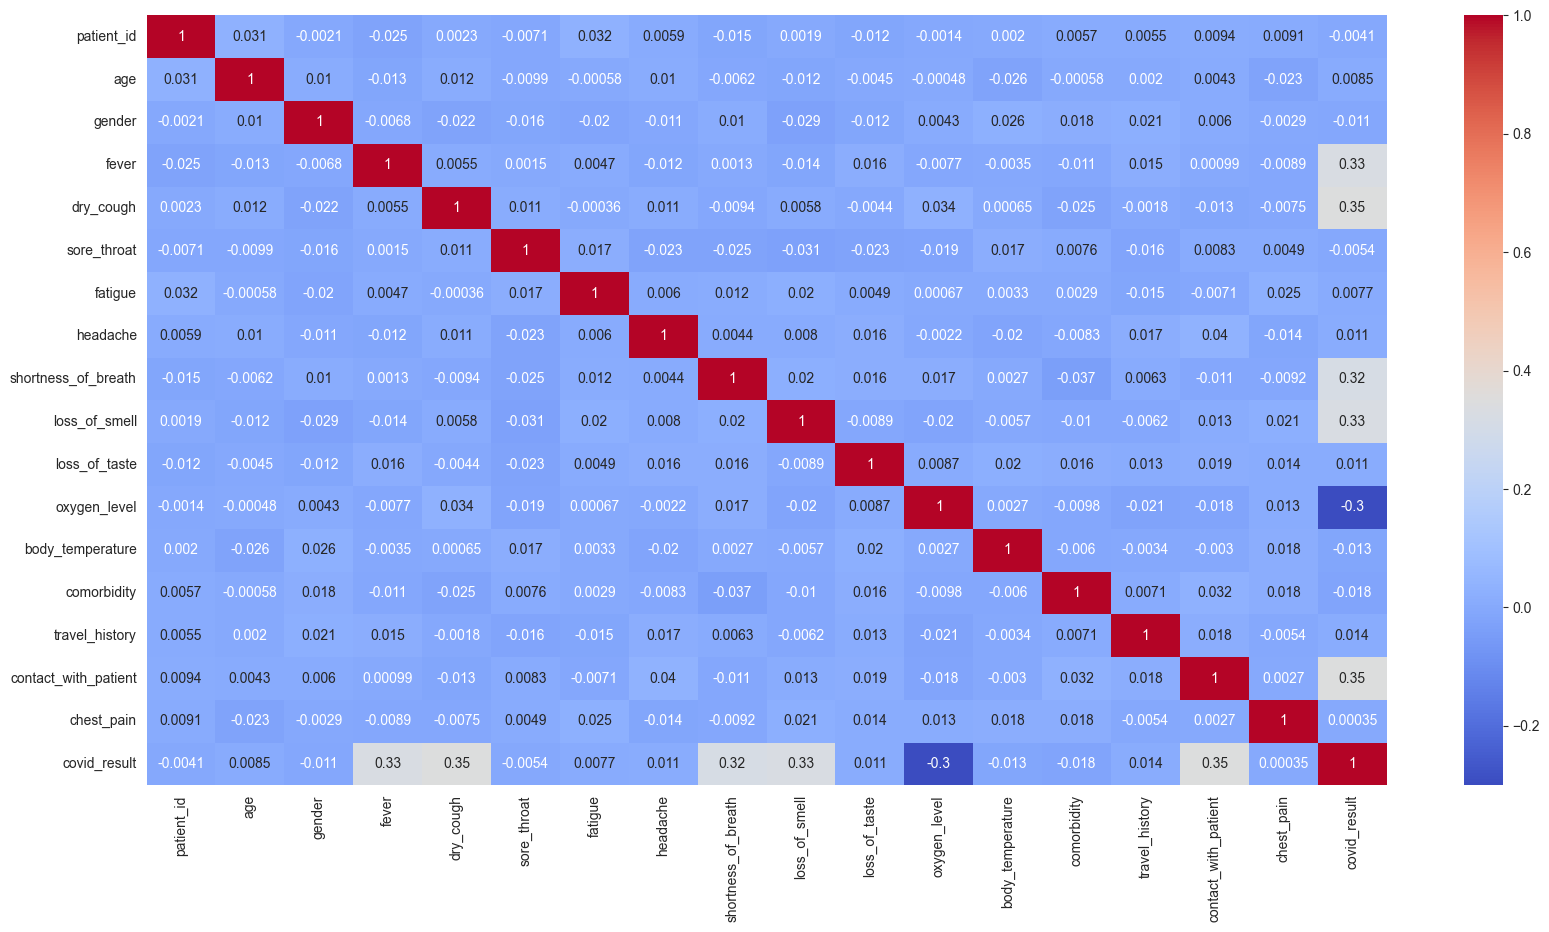

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
df['gender'] = df['gender'].astype('category').map({'Male': 0, 'Female': 1})
df['comorbidity'] = df['comorbidity'].map({'Asthma': 0, 'Diabetes': 1, 'Heart Disease': 2, 'no chronic disease': 3})

plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [156]:
df = pd.read_csv("/Users/bujjamma/Downloads/project_datasets/covid19_patient_symptoms_diagnosis.csv")
print(df.isnull().sum())

patient_id                 0
age                        0
gender                     0
fever                      0
dry_cough                  0
sore_throat                0
fatigue                    0
headache                   0
shortness_of_breath        0
loss_of_smell              0
loss_of_taste              0
oxygen_level               0
body_temperature           0
comorbidity             2725
travel_history             0
contact_with_patient       0
chest_pain                 0
covid_result               0
dtype: int64


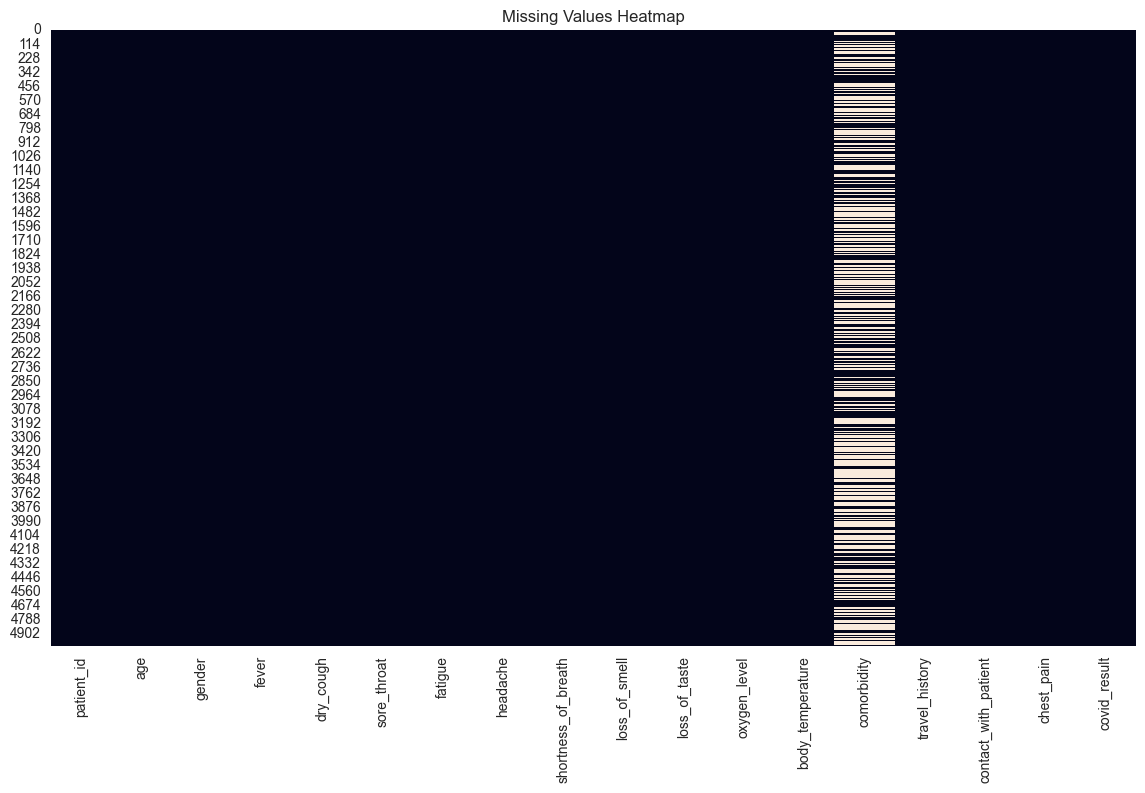

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### Data Cleaning

In [158]:
df["comorbidity"] = df["comorbidity"].fillna("no chronic disease")

In [159]:
print(df.isnull().sum())

patient_id              0
age                     0
gender                  0
fever                   0
dry_cough               0
sore_throat             0
fatigue                 0
headache                0
shortness_of_breath     0
loss_of_smell           0
loss_of_taste           0
oxygen_level            0
body_temperature        0
comorbidity             0
travel_history          0
contact_with_patient    0
chest_pain              0
covid_result            0
dtype: int64


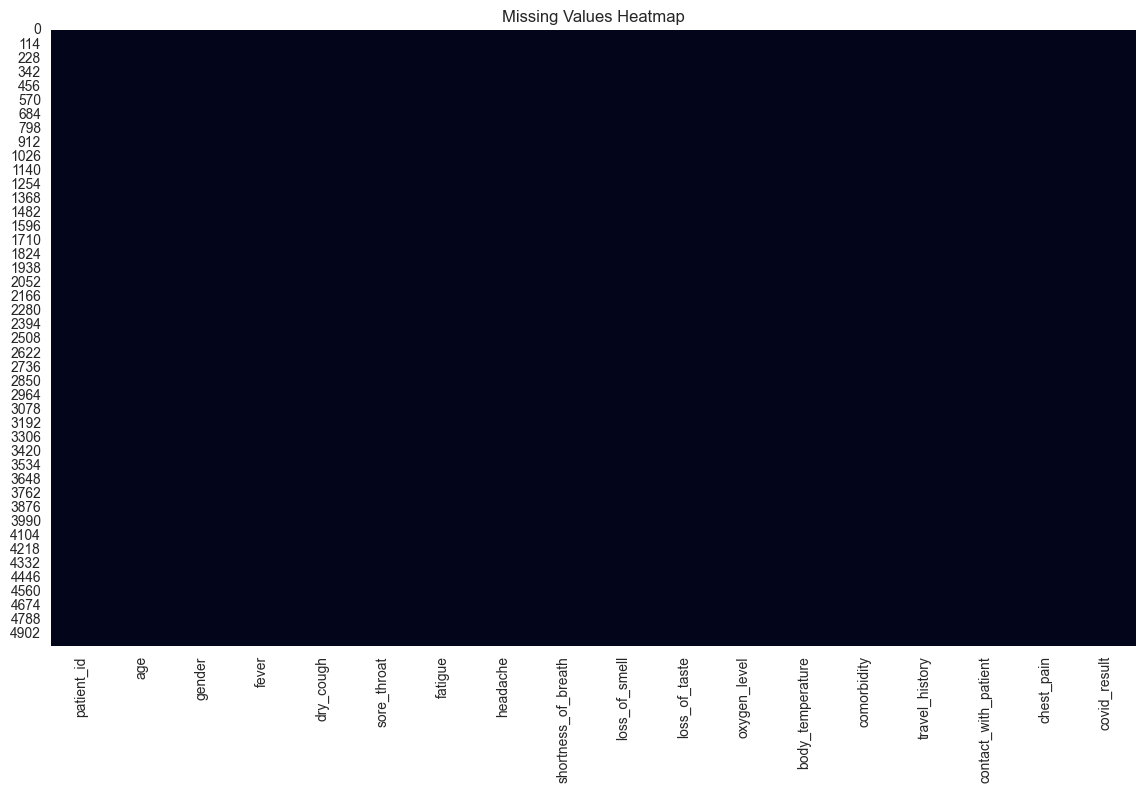

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [161]:
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool


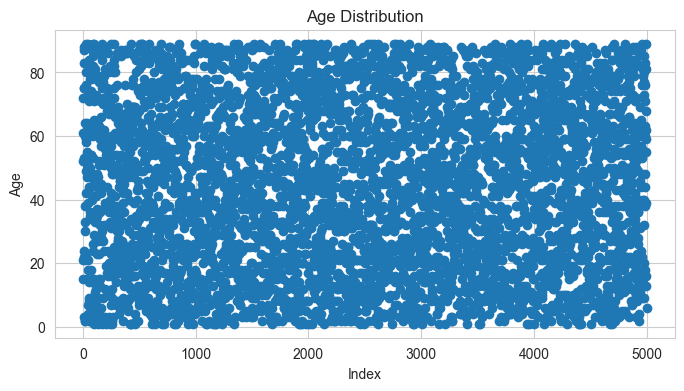

In [162]:
plt.figure(figsize=(8,4))
plt.scatter(range(len(df['age'])), df['age'])
plt.title("Age Distribution")
plt.xlabel("Index")
plt.ylabel("Age")
plt.show()

### Detecting Outliers

In [163]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_upper = df[df['age'] > upper_bound]
outliers_lower = df[df['age'] < lower_bound]

print(outliers_upper)
print(outliers_lower)

Empty DataFrame
Columns: [patient_id, age, gender, fever, dry_cough, sore_throat, fatigue, headache, shortness_of_breath, loss_of_smell, loss_of_taste, oxygen_level, body_temperature, comorbidity, travel_history, contact_with_patient, chest_pain, covid_result]
Index: []
Empty DataFrame
Columns: [patient_id, age, gender, fever, dry_cough, sore_throat, fatigue, headache, shortness_of_breath, loss_of_smell, loss_of_taste, oxygen_level, body_temperature, comorbidity, travel_history, contact_with_patient, chest_pain, covid_result]
Index: []


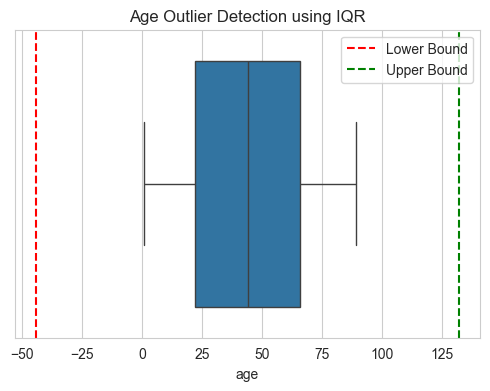

In [164]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['age'])

plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')

plt.title("Age Outlier Detection using IQR")
plt.legend()

plt.show()

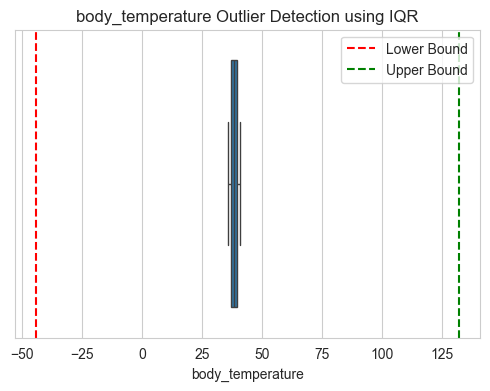

In [165]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['body_temperature'])

plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')

plt.title("body_temperature Outlier Detection using IQR")
plt.legend()

plt.show()

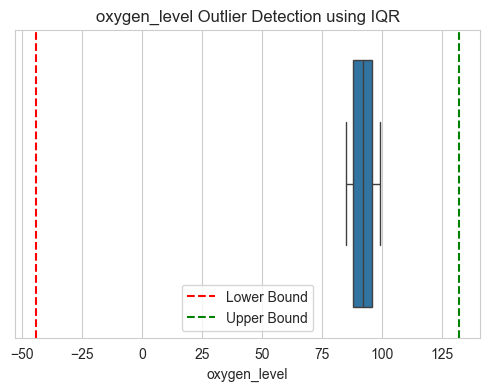

In [166]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['oxygen_level'])

plt.axvline(lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(upper_bound, color='green', linestyle='--', label='Upper Bound')

plt.title("oxygen_level Outlier Detection using IQR")
plt.legend()

plt.show()

In [167]:
comorbidity_summary = df['comorbidity'].value_counts()
print(comorbidity_summary)

comorbidity
no chronic disease    2725
Diabetes              1001
Heart Disease          792
Asthma                 482
Name: count, dtype: int64


In [168]:
print(df.dtypes)

patient_id                int64
age                       int64
gender                      str
fever                     int64
dry_cough                 int64
sore_throat               int64
fatigue                   int64
headache                  int64
shortness_of_breath       int64
loss_of_smell             int64
loss_of_taste             int64
oxygen_level              int64
body_temperature        float64
comorbidity                 str
travel_history            int64
contact_with_patient      int64
chest_pain                int64
covid_result              int64
dtype: object


In [169]:
df['gender'] = df['gender'].astype(str)
print(df.dtypes)

patient_id                int64
age                       int64
gender                      str
fever                     int64
dry_cough                 int64
sore_throat               int64
fatigue                   int64
headache                  int64
shortness_of_breath       int64
loss_of_smell             int64
loss_of_taste             int64
oxygen_level              int64
body_temperature        float64
comorbidity                 str
travel_history            int64
contact_with_patient      int64
chest_pain                int64
covid_result              int64
dtype: object


In [170]:
print(df.describe())

       patient_id      age    fever  dry_cough  sore_throat  fatigue  \
count    5,000.00 5,000.00 5,000.00   5,000.00     5,000.00 5,000.00   
mean     2,500.50    44.38     0.57       0.49         0.42     0.59   
std      1,443.52    25.55     0.50       0.50         0.49     0.49   
min          1.00     1.00     0.00       0.00         0.00     0.00   
25%      1,250.75    22.00     0.00       0.00         0.00     0.00   
50%      2,500.50    44.00     1.00       0.00         0.00     1.00   
75%      3,750.25    66.00     1.00       1.00         1.00     1.00   
max      5,000.00    89.00     1.00       1.00         1.00     1.00   

       headache  shortness_of_breath  loss_of_smell  loss_of_taste  \
count  5,000.00             5,000.00       5,000.00       5,000.00   
mean       0.44                 0.35           0.30           0.29   
std        0.50                 0.48           0.46           0.46   
min        0.00                 0.00           0.00           0.00   
2

In [171]:
print(df.duplicated().sum())

0


### Performing Groupby and Aggregation

In [172]:
print(df.groupby('comorbidity')['age'].agg(['mean', 'median', 'min', 'max', 'count']))

                    mean  median  min  max  count
comorbidity                                      
Asthma             43.72   44.00    1   89    482
Diabetes           44.66   45.00    1   89   1001
Heart Disease      43.87   44.00    1   89    792
no chronic disease 44.54   44.00    1   89   2725


In [173]:
bins = bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Elderly']

df['age_categories'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
print(df['age_categories'].value_counts())

table = pd.crosstab(df['covid_result'], df['age_categories'])
print(table)

df.groupby('age_categories')['covid_result'].mean()


age_categories
Adult      2397
Elderly    1628
Child       616
Teen        359
Name: count, dtype: int64
age_categories  Child  Teen  Adult  Elderly
covid_result                               
0                 295   179   1158      768
1                 321   180   1239      860


age_categories
Child     0.52
Teen      0.50
Adult     0.52
Elderly   0.53
Name: covid_result, dtype: float64

In [174]:
df['body_temperature'].unique()

array([37.1, 37.7, 36.8, 36. , 36.4, 39.8, 36.2, 38. , 40.9, 40. , 37.4,
       39.2, 38.5, 39.1, 38.2, 38.7, 37.6, 38.6, 38.1, 39.3, 39.9, 36.9,
       40.4, 40.3, 38.8, 36.6, 37.8, 40.2, 36.1, 39. , 36.5, 37.3, 39.4,
       40.8, 40.5, 38.9, 39.6, 37.5, 37.9, 40.7, 41. , 36.7, 39.7, 37.2,
       38.3, 39.5, 38.4, 36.3, 37. , 40.6, 40.1])

In [175]:
bins = bins = [35, 37, 39, 41]
labels = ['low', 'medium', 'high']

df['bodytemperature_categories'] = pd.cut(df['body_temperature'], bins=bins, labels=labels, right=False)
print(df['bodytemperature_categories'].value_counts())

table = pd.crosstab(df['covid_result'], df['bodytemperature_categories'])
print(table)

df.groupby('bodytemperature_categories')['covid_result'].mean()


bodytemperature_categories
high      2032
medium    1987
low        942
Name: count, dtype: int64
bodytemperature_categories  low  medium  high
covid_result                                 
0                           434     960   990
1                           508    1027  1042


bodytemperature_categories
low      0.54
medium   0.52
high     0.51
Name: covid_result, dtype: float64

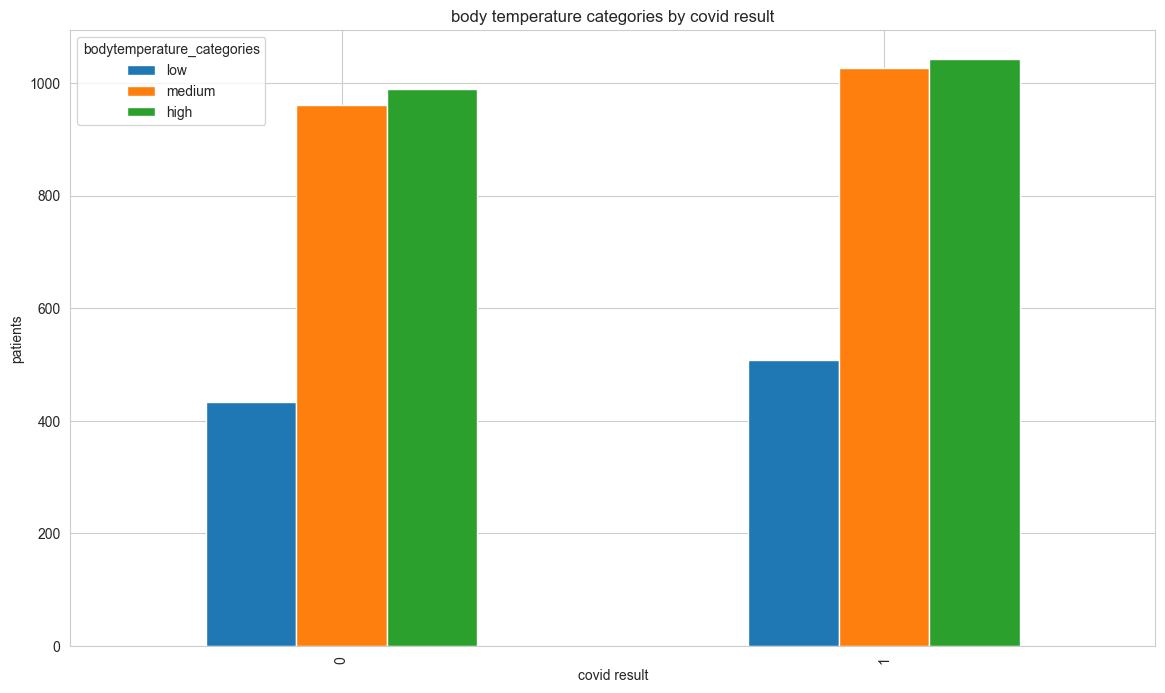

In [176]:
table.plot(kind='bar')
plt.title("body temperature categories by covid result")
plt.xlabel("covid result")
plt.ylabel("patients")
plt.show()

In [177]:
print(df.groupby('comorbidity')['covid_result'].value_counts())

comorbidity         covid_result
Asthma              1                252
                    0                230
Diabetes            1                510
                    0                491
Heart Disease       0                397
                    1                395
no chronic disease  1               1443
                    0               1282
Name: count, dtype: int64


In [178]:
print(df.groupby('oxygen_level')['covid_result'].value_counts())

oxygen_level  covid_result
85            1               222
              0               104
86            1               247
              0               100
87            1               245
              0               100
88            1               225
              0               102
89            1               255
              0                92
90            1               240
              0                97
91            1               252
              0                94
92            0               206
              1               109
93            0               234
              1               119
94            0               223
              1                98
95            0               212
              1               120
96            0               218
              1               123
97            0               213
              1               101
98            0               217
              1               122
99            0      

# Statistical Analysis & Hypothesis Testing 

### Finding the relationship between two categorical variables

### Contingency Table

In [179]:
contingency_table = pd.crosstab(df["comorbidity"],df["covid_result"])
print("contingency_table:-\n", contingency_table)

contingency_table:-
 covid_result           0     1
comorbidity                   
Asthma               230   252
Diabetes             491   510
Heart Disease        397   395
no chronic disease  1282  1443


### Visualization for contingency table

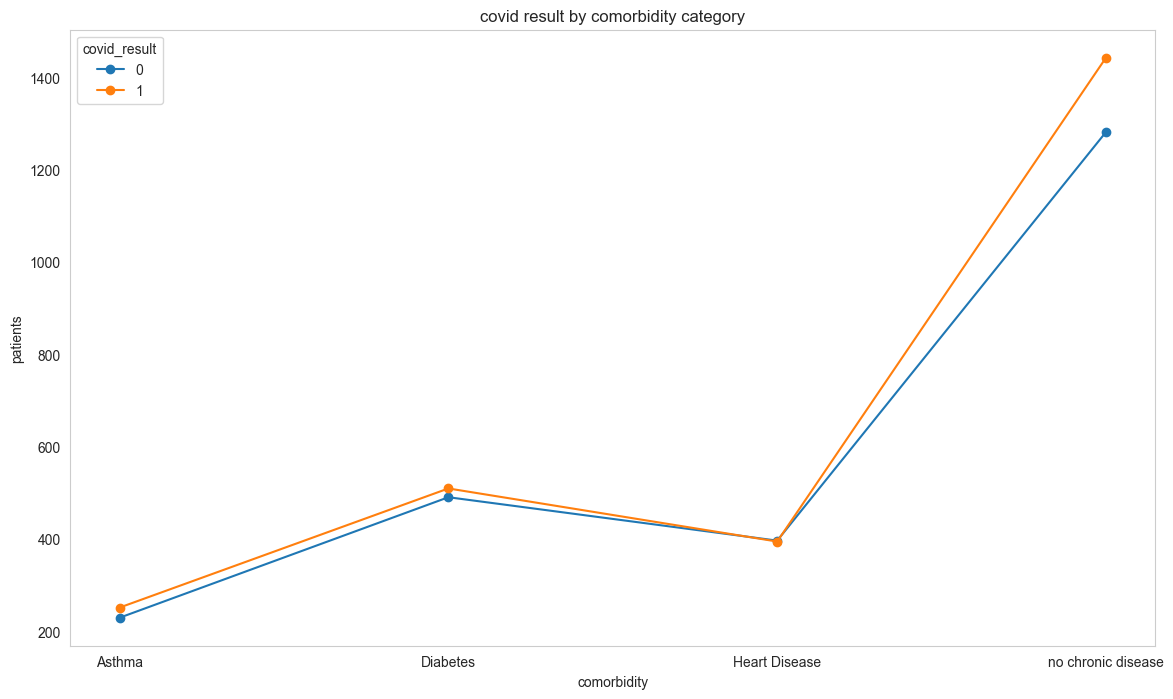

In [180]:
import matplotlib.pyplot as plt
contingency_table.plot(kind='line', marker='o')

plt.title("covid result by comorbidity category")
plt.xlabel("comorbidity")
plt.ylabel("patients")

plt.grid()
plt.show()

### Observed Values

In [181]:
observed_values = contingency_table.values
print("observed_values:-\n", observed_values)

observed_values:-
 [[ 230  252]
 [ 491  510]
 [ 397  395]
 [1282 1443]]


### Expected Values

In [182]:
import scipy.stats
b = scipy.stats.chi2_contingency(contingency_table)
expected_values = b[3]
print("expected_values:-\n", expected_values)

expected_values:-
 [[ 231.36  250.64]
 [ 480.48  520.52]
 [ 380.16  411.84]
 [1308.   1417.  ]]


### Degree of Freedom

In [183]:
no_of_rows=len(contingency_table.iloc[0:4,0])
no_of_columns=len(contingency_table.iloc[0,0:2])
degree_of_freedom =(no_of_rows-1)*(no_of_columns-1)
print("Degree of Freedom:-",degree_of_freedom)

Degree of Freedom:- 3


### Significance Level 5%

In [184]:
alpha = 0.05

### chi-square statistic - χ2

In [185]:
from scipy.stats import chi2
chi_square=sum([(o-e)**2./e for o,e in zip(observed_values,expected_values)])
chi_square_statistic=chi_square[0]+chi_square[1]
print("chi-square statistic:-",chi_square_statistic)

chi-square statistic:- 2.8867516238630535


### critical_value

In [186]:
critical_value=chi2.ppf(q=1-alpha,df=degree_of_freedom)
print('critical_value:',critical_value)

critical_value: 7.8147279032511765


### p-value

p_value=1-chi2.cdf(x=chi_square_statistic,df=degree_of_freedom)
print('p-value:',p_value)

In [187]:
print('Significance level: ',alpha)
print('Degree of Freedom: ',degree_of_freedom)
print('chi-square statistic:',chi_square_statistic)
print('critical_value:',critical_value)
print('p-value:',p_value)


Significance level:  0.05
Degree of Freedom:  3
chi-square statistic: 2.8867516238630535
critical_value: 7.8147279032511765
p-value: 0.4094174259942259


### compare chi_square_statistic with critical_value and p-value which is the probability of getting chi-square>0.09 (chi_square_statistic)

In [188]:
if chi_square_statistic>=critical_value:
    print("Reject H0,There is a relationship between 2 categorical variables")
else:
    print("Retain H0,There is no relationship between 2 categorical variables")
    
if p_value<=alpha:
    print("Reject H0,There is a relationship between 2 categorical variables")
else:
    print("Retain H0,There is no relationship between 2 categorical variables")

Retain H0,There is no relationship between 2 categorical variables
Retain H0,There is no relationship between 2 categorical variables


# Data Modeling

In [189]:
# Import libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/Users/bujjamma/Downloads/project_datasets/covid19_patient_symptoms_diagnosis.csv")

df = pd.get_dummies(df, drop_first=True)

# Split features and target
X = df.drop('covid_result', axis=1)   
y = df['covid_result']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# 1. Baseline Model
# Logistic Regression
# ---------------------------

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


# ---------------------------
# 2. Advanced Model
# Random Forest
# ---------------------------

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))




=== Logistic Regression ===
Accuracy: 0.987
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       505
           1       0.98      0.99      0.99       495

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


=== Random Forest ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       505
           1       1.00      1.00      1.00       495

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



### Visualization part for Data Modeling

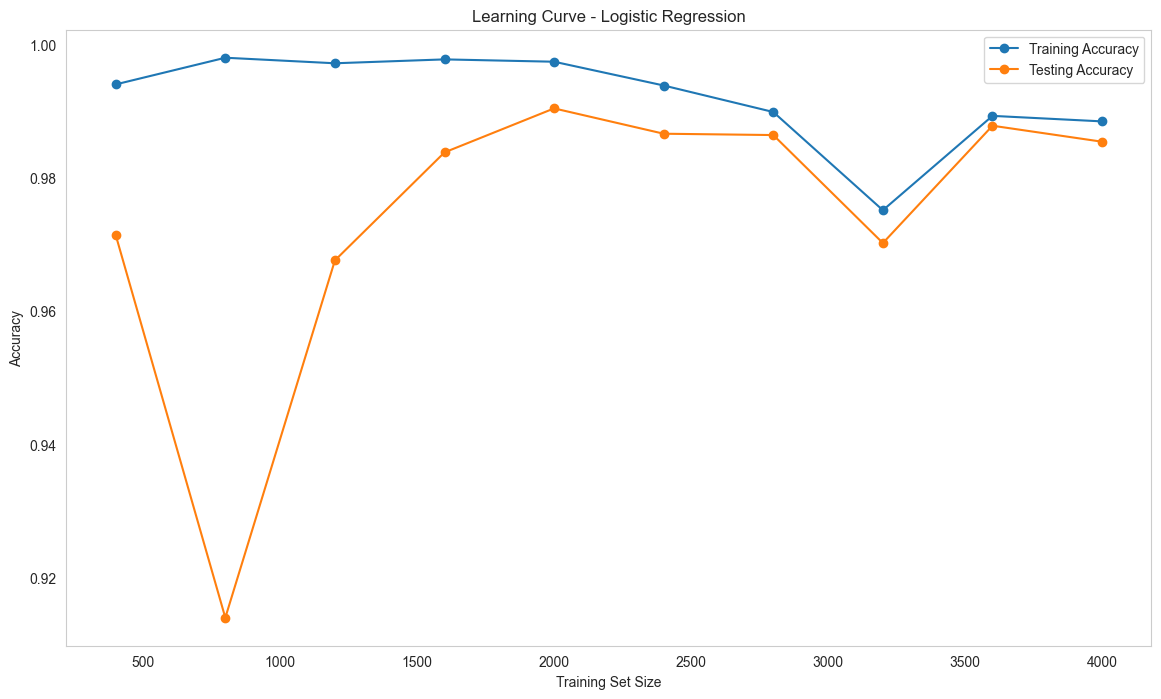

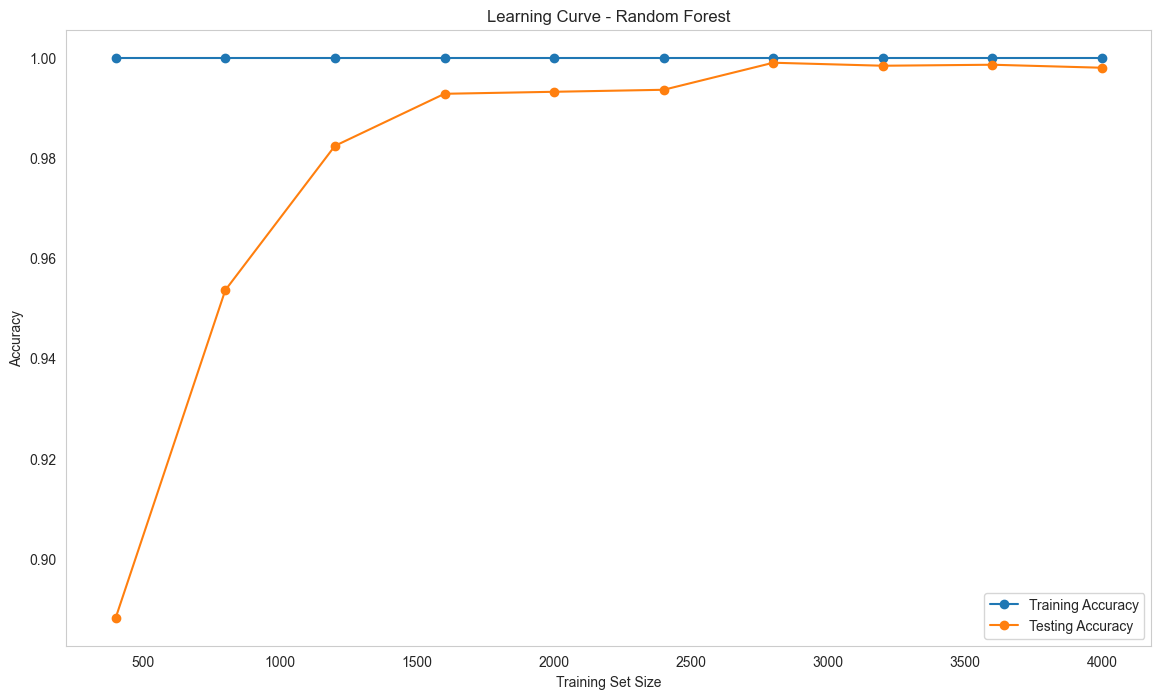

In [190]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, marker='o', label="Training Accuracy")
    plt.plot(train_sizes, test_mean, marker='o', label="Testing Accuracy")

    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()

    plt.show()


# Logistic Regression Curve
plot_learning_curve(lr, X, y, "Learning Curve - Logistic Regression")

# Random Forest Curve
plot_learning_curve(rf, X, y, "Learning Curve - Random Forest")